# Geração de Imagens e Treinamento Ângulo-Ordem (Order-CWT)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Metodologia:** Computed Order Tracking (COT) + Continuous Wavelet Transform  
**Objetivo:** Gerar escalogramas no domínio de ordens (amostras uniformes por volta do eixo) e treinar as arquiteturas convolucionais (`BearingCNN` e `ResNet-18`) com invariância à rotação (RPM).

---

## 1. Importação de Módulos e Configurações

In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == '4_order_tracking' else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    ORDER_CWRU_DIR,
    ORDER_PADERBORN_DIR,
    NUM_EPOCHS,
    LEARNING_RATE,
    RANDOM_SEED
)
from src.generate_order_dataset import generate_cwru_order_dataset, generate_paderborn_order_dataset
from src.transfer_learning import train_and_evaluate_transfer_model
from src.cnn_processor import train_and_evaluate_bearing_cnn
from src.visualization import plot_training_curves, plot_confusion_matrix

## 2. Geração Automática dos Escalogramas Ângulo-Ordem (Order-CWT)

Gera os datasets em `data/order_tracking/cwru/` e `data/order_tracking/paderborn/` sem Data Leakage.

In [3]:
# 1. Gerar escalogramas de ordens para o CWRU
generate_cwru_order_dataset()

# 2. Gerar escalogramas de ordens para o Paderborn (10 arquivos por classe para teste rápido)
generate_paderborn_order_dataset(max_files_per_class=10)

 GERAÇÃO DO DATASET ÂNGULO-ORDEM (ORDER-CWT) — CWRU
    1024 amostras/volta | Janela: 4 voltas | Ordens: 0.5-15.0
    ✅ CWRU     normal (train): 2 arquivos -> 889 imagens geradas
    ✅ CWRU     normal (  val): 1 arquivos -> 594 imagens geradas
    ✅ CWRU     normal ( test): 1 arquivos -> 582 imagens geradas
    ✅ CWRU inner_race (train): 8 arquivos -> 1178 imagens geradas
    ✅ CWRU inner_race (  val): 2 arquivos -> 297 imagens geradas
    ✅ CWRU inner_race ( test): 2 arquivos -> 299 imagens geradas
    ✅ CWRU outer_race (train): 8 arquivos -> 1178 imagens geradas
    ✅ CWRU outer_race (  val): 2 arquivos -> 298 imagens geradas
    ✅ CWRU outer_race ( test): 2 arquivos -> 300 imagens geradas
    ✅ CWRU       ball (train): 8 arquivos -> 1176 imagens geradas
    ✅ CWRU       ball (  val): 2 arquivos -> 299 imagens geradas
    ✅ CWRU       ball ( test): 2 arquivos -> 299 imagens geradas

[+] Total de imagens CWRU geradas em: C:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-dia

## 3. Treinamento da ResNet-18 no Dataset CWRU Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.0841 - Acc: 97.33% | Val Loss: 0.0059 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0096 - Acc: 99.68% | Val Loss: 0.0012 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0023 - Acc: 99.98% | Val Loss: 0.0015 - Acc: 100.00% 
Época [04/10] | Treino Loss: 0.0005 - Acc: 100.00% | Val Loss: 0.0013 - Acc: 100.00% 
Época [05/10] | Treino Loss: 0.0077 - Acc: 99.86% | Val Loss: 0.0017 - Acc: 100.00% 
Época [06/10] | Treino Loss: 0.0216 - Acc: 99.28% | Val Loss: 0.0053 - Acc: 99.93% 
Época [07/10] | Treino Loss: 0.0024 - Acc: 99.95% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0046 - Acc: 99.91% | Val Loss: 0.0008 - Acc: 100.00% 
Época [09/10] | Treino Loss: 0.0013 - Acc: 99.98% | Val Loss: 0.0010 - Acc: 100.00% 
Época [1

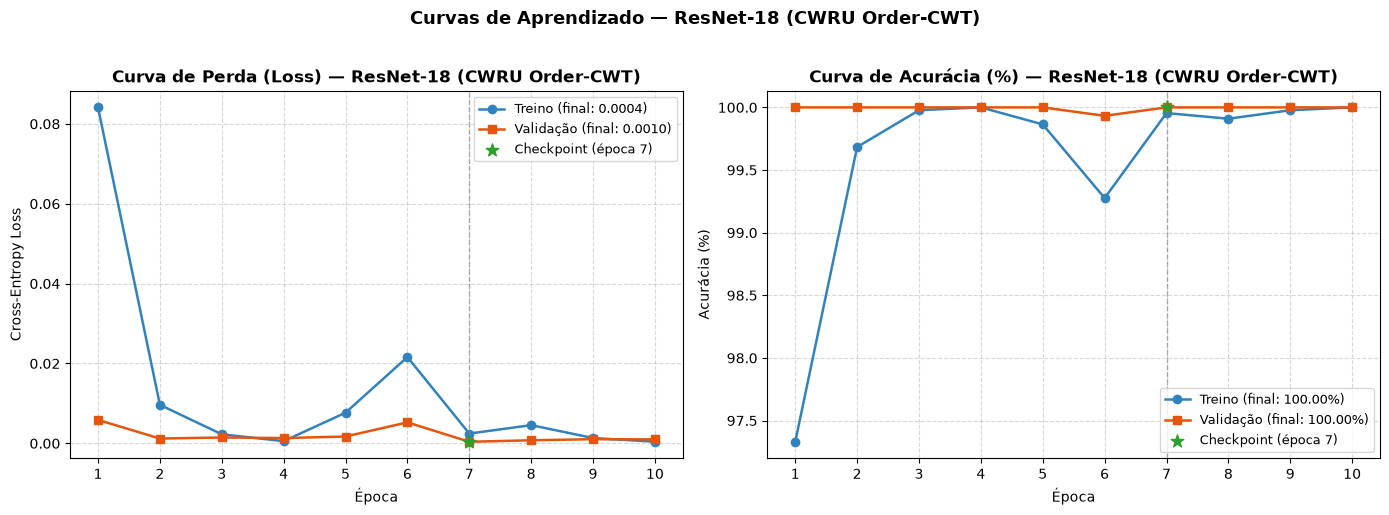

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_cwru_resnet.png


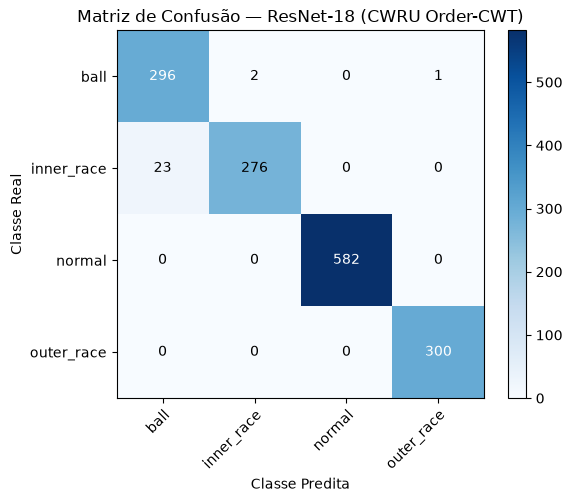

In [4]:
res_cwru_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_CWRU_DIR,
    checkpoint_prefix="checkpoint_order_cwru"
)

plot_training_curves(
    res_cwru_order['history'],
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/training_curves_order_cwru_resnet.png"
)

plot_confusion_matrix(
    res_cwru_order,
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_cwru_resnet.png"
)

## 4. Treinamento da ResNet-18 no Dataset Paderborn Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.7070 - Acc: 66.50% | Val Loss: 0.5859 - Acc: 77.01% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.1489 - Acc: 95.89% | Val Loss: 0.1141 - Acc: 98.85% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0659 - Acc: 98.19% | Val Loss: 0.1109 - Acc: 97.70% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0310 - Acc: 99.34% | Val Loss: 0.0784 - Acc: 96.55% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0207 - Acc: 99.67% | Val Loss: 0.0569 - Acc: 97.70% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0128 - Acc: 99.67% | Val Loss: 0.0712 - Acc: 98.85% 
Época [07/10] | Treino Loss: 0.0070 - Acc: 100.00% | Val Loss: 0.0862 - Acc: 97.70% 
Época [08/10] | Treino Loss: 0.0094 - Acc: 99.84% | Val Loss: 0.0696 - Acc: 97.70% 
Época 

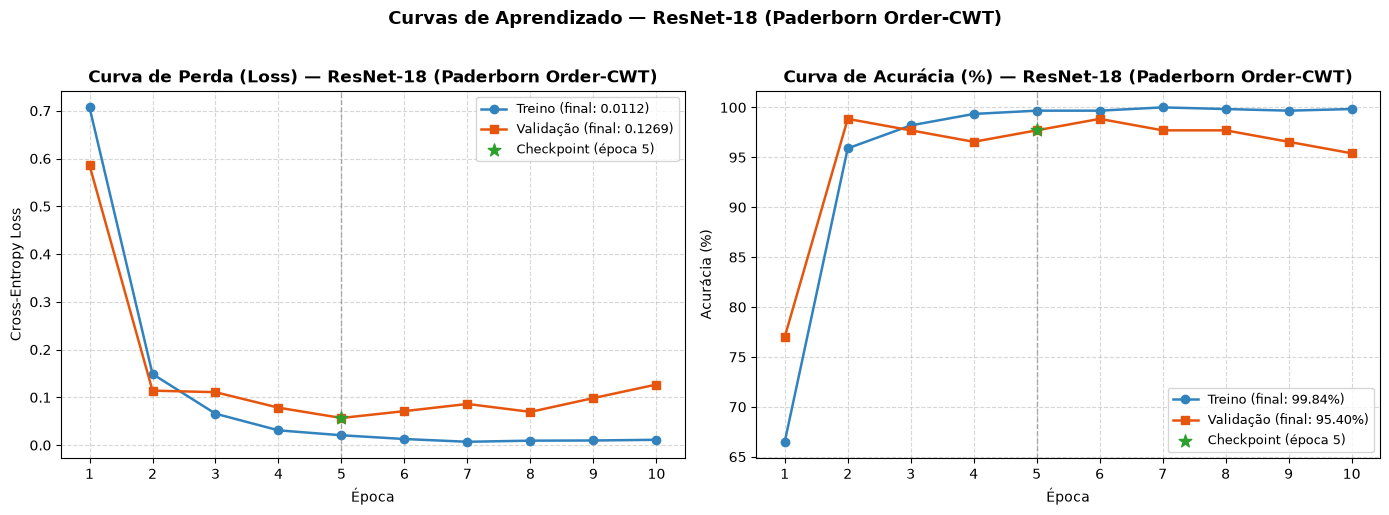

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_paderborn_resnet.png


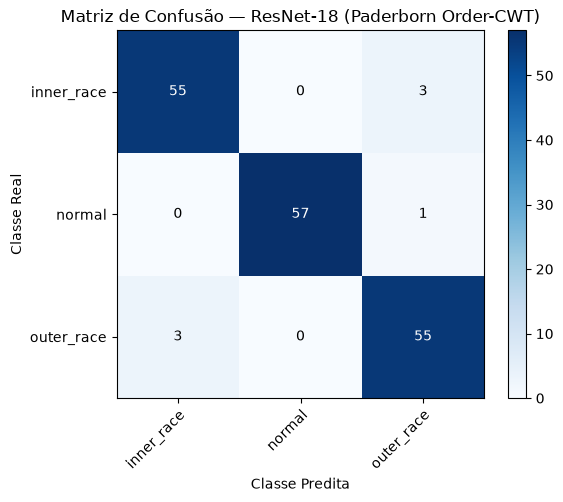

In [5]:
res_pad_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_PADERBORN_DIR,
    checkpoint_prefix="checkpoint_order_paderborn"
)

plot_training_curves(
    res_pad_order['history'],
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/training_curves_order_paderborn_resnet.png"
)

plot_confusion_matrix(
    res_pad_order,
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_paderborn_resnet.png"
)